Root Mean Squared Error (RMSE): 0.8108
R-squared (R²) Score: 0.4983



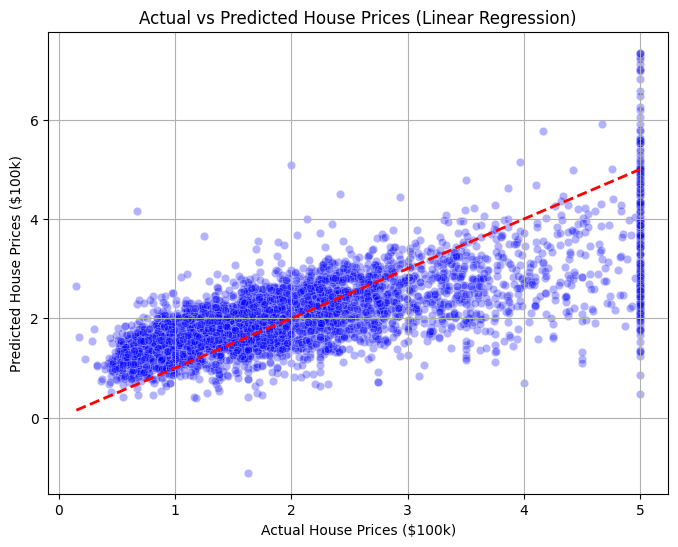

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Built-in California Housing Dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# 2. Select 4 Key Features (Most relevant for prices)
# MedInc: Median Income, AvgRooms: Average Rooms, HouseAge: House Age, AveOccup: Average Occupancy
selected_features = ['MedInc', 'AveRooms', 'HouseAge', 'AveOccup'] # Corrected 'AvgRooms' to 'AveRooms'
X = df[selected_features]
y = df['MedHouseVal']  # Target: Median House Value (in $100k)

# 3. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Predictions & Evaluation
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²) Score: {r2:.4f}\n")

# 6. Scatter Plot: Actual vs Predicted Prices
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Ideal line
plt.xlabel("Actual House Prices ($100k)")
plt.ylabel("Predicted House Prices ($100k)")
plt.title("Actual vs Predicted House Prices (Linear Regression)")
plt.grid(True)
plt.show()